<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 6, Transformers Series de Tiempo**

Instalamos lo necesario

In [ ]:
!pip install -q neuralforecast statsforecast datasetsforecast

Importamos lo necesario

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import warnings, time, logging
warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

from datasetsforecast.long_horizon import LongHorizon # loader de ETTh1
from neuralforecast import NeuralForecast  # orquestador DL
from neuralforecast.models import Informer, Autoformer, TFT, PatchTST
from neuralforecast.losses.pytorch import MAE as MAEloss # loss diferenciable
from statsforecast import StatsForecast # orquestador clasico
from statsforecast.models import SeasonalNaive, AutoETS

Definimos hiperparámetros

In [ ]:
H = 96 # horizonte: cuantos pasos (horas) predice el modelo por ventana, 96 h = 4 dias
L = 336 # input_size: cuantas horas pasadas ve el modelo, 336 h = 14 dias

# 2880 h = 120 dias = Aprox 4 meses cada uno
VAL = 2880 # se usa para early stopping
TEST = 2880

# longitud del ciclo estacional dominante: 24 horas (patron diario),
# solo lo consumen los modelos clasicos; los transformers lo aprenden solos
SEASON = 24

# Máximo de pasos de gradiente (batches) por modelo, no son epochs
MAX_STEPS = 500

Cargamos los datos

LongHorizon.load devuelve una tupla (Y_df, X_df, S_df):
* Y_df = la(s) serie(s) objetivo
* X_df = covariables exogenas
* S_df = covariables estaticas.

Aqui solo nos interesa Y_df, los otros dos se descartan porque este experimento es univariante puro

In [ ]:
Y_df, _, _ = LongHorizon.load(directory="./data", group="ETTh1")

Convertimos a datetime real

In [ ]:
Y_df["ds"] = pd.to_datetime(Y_df["ds"])

Formato de Nixtla (long format):
* unique_id: identificador de la serie
* ds: timestamp
* y: valor observado


In [ ]:
Y_df = Y_df[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"])

Se extraen los nombres reales de las series

In [ ]:
SERIES = sorted(Y_df.unique_id.unique())

In [ ]:
print(f"{len(Y_df)} filas, series: {SERIES} | {Y_df.ds.min()} a {Y_df.ds.max()}")
print(f"Backtesting: {TEST // H} ventanas de {H} h")

14400 filas, series: ['OT'] | 2016-07-01 00:00:00 a 2018-02-20 23:00:00
Backtesting: 30 ventanas de 96 h


Definimos los transformers

Definimos la variable comun que agrupa todo lo que debe ser identico entre modelos

In [ ]:
comun = dict(
    h=H,                             # horizonte de salida
    input_size=L,                    # ventana de contexto de entrada
    loss=MAEloss(),                  # funcion de perdida: error absoluto medio.
                                     #   MAE (L1) es mas robusto a outliers que MSE;
                                     #   ETTh1 tiene picos, por eso se prefiere.
    max_steps=MAX_STEPS,             # presupuesto de pasos de optimizacion
    val_check_steps=50,              # evalua en validacion cada 50 pasos
    early_stop_patience_steps=5,     # para si 5 evaluaciones seguidas (=250 pasos)
                                     #   no mejoran la loss de validacion
    batch_size=32,                   # nº de SERIES por batch
    windows_batch_size=128,          # nº de VENTANAS (muestras) por paso de gradiente
    random_seed=42,                  # reproducibilidad (init de pesos, shuffling)
    enable_progress_bar=False,       # sin barra de progreso
)

NeuralForecast es el contenedor que entrena/predice todos los modelos a la vez.

freq="h" declara que la serie es horaria (usado para generar los timestamps futuros).

In [ ]:
nf = NeuralForecast(freq="h", models=[

    # INFORMER
    Informer(hidden_size=64, # dimension d_model de los embeddings internos
             n_head=4, # cabezas de atencion (64/4 = 16 dims por cabeza)
             encoder_layers=2, # bloques del encoder (procesan el pasado)
             decoder_layers=1, # bloques del decoder (generan el futuro)
             learning_rate=1e-3,  # LR alto: converge rapido en 500 pasos
             scaler_type="standard",# normalizacion z-score por serie ((x-mu)/sigma).
                                    # las 7 series de ETTh1 estan en escalas muy distintas.
             **comun),


    # AUTOFORMER
    Autoformer(hidden_size=64, n_head=4, encoder_layers=2, decoder_layers=1,
               learning_rate=1e-3, scaler_type="standard", **comun),


    # TFT — Temporal Fusion Transformer
    TFT(hidden_size=64, n_head=4,
        dropout=0.1, # regularizacion moderada
        learning_rate=1e-3,
        scaler_type="robust",  # normaliza con mediana en vez de media/desviacion, menos sensible a outliers
        **comun),


    # PATCHTST
    PatchTST(patch_len=16, # longitud de cada parche
             stride=8, # salto entre parches, 50% de solapamiento
             revin=True, # activa la normalizacion reversible
             hidden_size=128, # modelo mas ancho que los anteriores
             n_heads=16,
             encoder_layers=3,  # mas profundo (solo tiene encoder, sin decoder)
             linear_hidden_size=256, # ancho de la cabeza lineal de proyeccion final
             dropout=0.2,   # mas dropout porque el modelo es mas grande
             learning_rate=1e-34, #LR menor, PatchTST es inestable con LR alto
             scaler_type="identity", # Sin escalado externo,
             **comun),
])

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42


Cross-validation

* n_windows=None, deduce el numero de ventanas a partir de test_size
* step_size=H, avanza 96 h entre ventanas, ventanas SIN solape.


In [ ]:
cv_nf = nf.cross_validation(df=Y_df, val_size=VAL, test_size=TEST,
                            n_windows=None, step_size=H).reset_index()

Baseline clásico

In [ ]:
sf = StatsForecast(
    freq="h",
    n_jobs=-1,     # paraleliza sobre todos los nucleos de CPU disponibles
    models=[
        # SeasonalNaive: predice y(t) = y(t - 24). Literalmente "manana a esta
        # hora sera igual que hoy a esta hora". Coste computacional ~0.
        # Sorprendentemente dificil de batir en series muy estacionales.
        SeasonalNaive(season_length=SEASON)
    ])

Replicamos el mismo esquema de backtesting

In [ ]:
cv_sf = sf.cross_validation(df=Y_df, h=H, step_size=H,
                            n_windows=TEST // H).reset_index()

reset_index() sobre un df con indice nombrado deja una columna residual llamada "index" (o "level_0"). Si sobrevive el merge de abajo la duplica como index_x / index_y y todo el codigo posterior falla con KeyError. Se elimina de forma defensiva (solo si existe)

In [ ]:
for _df in (cv_nf, cv_sf):
    _df.drop(columns=[c for c in ("index", "level_0") if c in _df.columns],
             inplace=True)

Declaramos las solumnas que NO son predicciones de un modelo: metadatos y el valor real

In [ ]:
NO_MODELO = ("unique_id", "ds", "cutoff", "y")

Todo lo demas es una columna de predicciones

In [ ]:
cols_nf = [c for c in cv_nf.columns if c not in NO_MODELO]   # transformers
cols_sf = [c for c in cv_sf.columns if c not in NO_MODELO]   # clasicos

Se juntan ambos resultados en una unica tabla.
* Se dropean 'y' y 'cutoff' del lado clasico, ya vienen en cv_nf
* Clave del join: (unique_id, ds) a misma serie, mismo instante.
* how="inner": conserva solo las filas presentes en ambos, garantizando que todos los modelos se evaluen sobre exactamente el mismo conjunto de puntos.

In [ ]:
cv = cv_nf.merge(cv_sf.drop(columns=[c for c in ("y", "cutoff") if c in cv_sf.columns]),
                 on=["unique_id", "ds"], how="inner")

Reordenar para graficar y

In [ ]:
cv = cv.sort_values(["unique_id", "cutoff", "ds"]).reset_index(drop=True)

'paso' = posicion dentro del horizonte (1 = primera hora predicha, 96 = ultima), permite despues medir COMO se degrada el error a medida que se aleja la prediccion.

In [ ]:
cv["paso"] = cv.groupby(["unique_id", "cutoff"]).cumcount() + 1   # 1..96

In [ ]:
todos = cols_sf + cols_nf

Tabla de métricas agregadas

In [ ]:
res = pd.DataFrame({
    m: {"MAE": (cv[m] - cv.y).abs().mean(),
        "MSE": ((cv[m] - cv.y) ** 2).mean(),
        "RMSE": np.sqrt(((cv[m] - cv.y) ** 2).mean())}
    for m in todos
}).T.sort_values("MSE")

In [ ]:
res["vs_baseline_%"] = (1 - res.MSE / res.loc[cols_sf, "MSE"].min()) * 100

In [ ]:
print(res.round(4).to_string())     # to_string evita que pandas trunque columnas
print("Mejor:", res.index[0])   # primera fila = menor MSE

                  MAE     MSE    RMSE  vs_baseline_%
PatchTST       0.2032  0.0670  0.2588         0.1241
SeasonalNaive  0.2063  0.0671  0.2590         0.0000
TFT            0.2065  0.0697  0.2640        -3.9153
Autoformer     0.2087  0.0712  0.2669        -6.1971
Informer       0.2682  0.1037  0.3220       -54.6580
Mejor: PatchTST


Error medio por paso del horizonte

Matriz de errores absolutos: una columna por modelo, una fila por observacion

In [ ]:
err = pd.DataFrame({m: (cv[m] - cv.y).abs() for m in todos})
err["paso"] = cv["paso"].values  # .values evita desalineacion por indices

Promediando por 'paso' se obtiene la curva de degradacion

In [ ]:
por_paso = err.groupby("paso").mean()

Helpers para dibujo


Graficando serie 'OT' | 30 ventanas disponibles


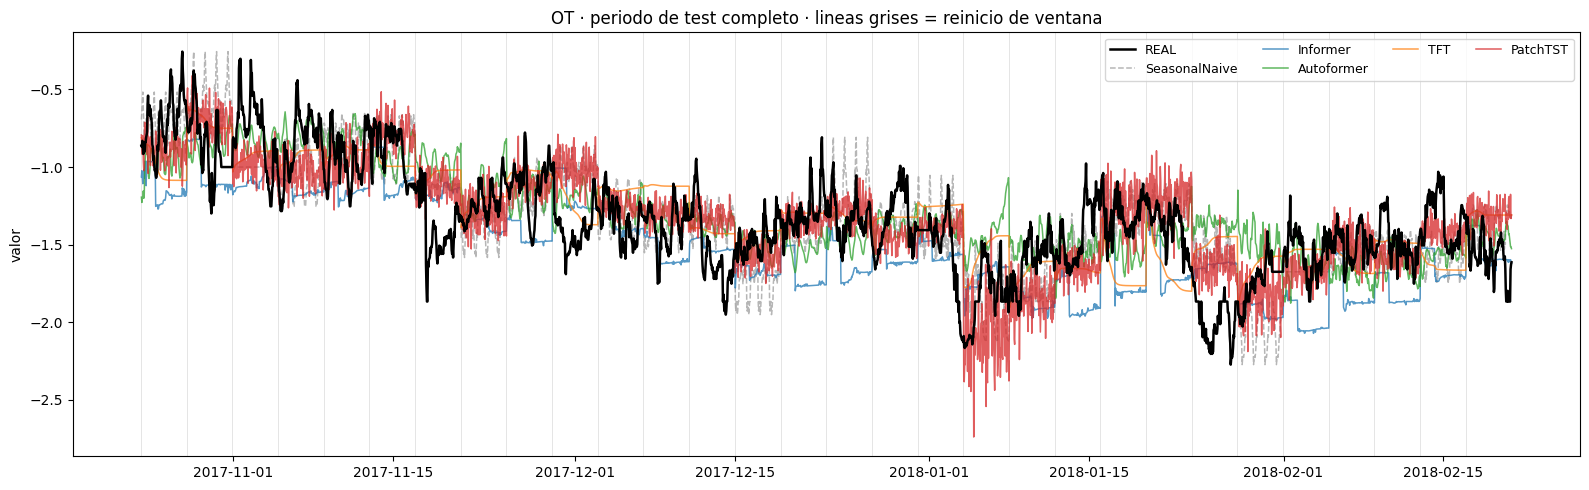

In [ ]:
COLORES = {"SeasonalNaive": "#9e9e9e", "AutoETS": "#616161", "AutoARIMA": "#424242",
           "Informer": "#1f77b4", "Autoformer": "#2ca02c",
           "TFT": "#ff7f0e", "PatchTST": "#d62728"}

color  = lambda m: COLORES.get(m, "#777777")   # gris neutro si el modelo no esta mapeado
base   = lambda m: m in cols_sf                # True si es un baseline clasico
estilo = lambda m: dict(color=color(m),
                        lw=1.3 if base(m) else 2.1,   # baselines mas finos
                        ls="--" if base(m) else "-")  # baselines discontinuos


SERIE = SERIES[0]
sub = cv[cv.unique_id == SERIE].sort_values(["cutoff", "ds"])


CUTOFFS = sorted(sub.cutoff.unique())
print(f"\nGraficando serie '{SERIE}' | {len(CUTOFFS)} ventanas disponibles")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sub.ds, sub.y, color="black", lw=1.8, label="REAL", zorder=10)

for m in todos:
    # {**estilo(m), "lw": 1.1} = toma el estilo base del modelo y sobreescribe
    # solo el grosor. Al pintar 4 meses, lineas finas evitan el emborronado.
    ax.plot(sub.ds, sub[m], label=m, alpha=0.75, **{**estilo(m), "lw": 1.1})

# Una linea gris vertical en cada cutoff: marca donde el modelo "reinicia" con
# datos reales. Suele verse un salto/discontinuidad justo ahi.
for c in CUTOFFS:
    ax.axvline(pd.Timestamp(c), color="0.88", lw=0.6, zorder=0)

ax.set_title(f"{SERIE} · periodo de test completo · lineas grises = reinicio de ventana")
ax.set_ylabel("valor"); ax.legend(ncol=4, fontsize=9)
fig.tight_layout()
plt.show()